# 3-DOF Mass-Spring-Damper System

We consider the 3-degree-of-freedom damped forced vibration system governed by

$$
\mathbf{M}\ddot{\mathbf{x}} + \mathbf{C}\dot{\mathbf{x}} + \mathbf{K}\mathbf{x} = \mathbf{F}(t)
$$

where:

- $\mathbf{M}$ is the **mass matrix**
- $\mathbf{C}$ is the **damping matrix**
- $\mathbf{K}$ is the **stiffness matrix**
- $\mathbf{x}$ is the **displacement vector**
- $\dot{\mathbf{x}}$ is the **velocity vector**
- $\ddot{\mathbf{x}}$ is the **acceleration vector**
- $\mathbf{F}(t)$ is the **external force vector**


<p align="center">
<img src="image.png" width="400">
</p>

---

## Displacement, Velocity, and Acceleration Vectors

$$
\mathbf{x}(t)=
\begin{bmatrix}
x_1(t) \\
x_2(t) \\
x_3(t)
\end{bmatrix}
$$

$$
\dot{\mathbf{x}}(t)=
\begin{bmatrix}
\dot{x}_1(t) \\
\dot{x}_2(t) \\
\dot{x}_3(t)
\end{bmatrix}
$$

$$
\ddot{\mathbf{x}}(t)=
\begin{bmatrix}
\ddot{x}_1(t) \\
\ddot{x}_2(t) \\
\ddot{x}_3(t)
\end{bmatrix}
$$

---

## Mass Matrix

$$
\mathbf{M}=
\begin{bmatrix}
m_1 & 0 & 0 \\
0 & m_2 & 0 \\
0 & 0 & m_3
\end{bmatrix}
$$

The mass matrix is diagonal because each degree of freedom has its own lumped mass.

---

## Damping Matrix

$$
\mathbf{C}=
\begin{bmatrix}
c_1+c_2 & -c_2 & 0 \\
-c_2 & c_2+c_3 & -c_3 \\
0 & -c_3 & c_3
\end{bmatrix}
$$

The damping matrix represents viscous damping effects between connected masses and supports.

---

## Stiffness Matrix

$$
\mathbf{K}=
\begin{bmatrix}
k_1+k_2 & -k_2 & 0 \\
-k_2 & k_2+k_3 & -k_3 \\
0 & -k_3 & k_3
\end{bmatrix}
$$

The stiffness matrix describes how the springs resist displacement.

---

## Force Vector

For a general external excitation,

$$
\mathbf{F}(t)=
\begin{bmatrix}
F_1(t) \\
F_2(t) \\
F_3(t)
\end{bmatrix}
$$

If sinusoidal forces are applied, one possible form is

$$
\mathbf{F}(t)=
\begin{bmatrix}
F_{01}\sin(\omega_1 t) \\
F_{02}\sin(\omega_2 t) \\
F_{03}\sin(\omega_3 t)
\end{bmatrix}
$$

where:

- $F_{01}, F_{02}, F_{03}$ are force amplitudes
- $\omega_1, \omega_2, \omega_3$ are forcing frequencies

---

## Equation of Motion in Expanded Form

The matrix equation

$$
\mathbf{M}\ddot{\mathbf{x}} + \mathbf{C}\dot{\mathbf{x}} + \mathbf{K}\mathbf{x} = \mathbf{F}(t)
$$

can be written as

$$
\begin{bmatrix}
m_1 & 0 & 0 \\
0 & m_2 & 0 \\
0 & 0 & m_3
\end{bmatrix}
\begin{bmatrix}
\ddot{x}_1 \\
\ddot{x}_2 \\
\ddot{x}_3
\end{bmatrix}
+
\begin{bmatrix}
c_1+c_2 & -c_2 & 0 \\
-c_2 & c_2+c_3 & -c_3 \\
0 & -c_3 & c_3
\end{bmatrix}
\begin{bmatrix}
\dot{x}_1 \\
\dot{x}_2 \\
\dot{x}_3
\end{bmatrix}
+
\begin{bmatrix}
k_1+k_2 & -k_2 & 0 \\
-k_2 & k_2+k_3 & -k_3 \\
0 & -k_3 & k_3
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
=
\begin{bmatrix}
F_1(t) \\
F_2(t) \\
F_3(t)
\end{bmatrix}
$$

---

## Numerical Form Used in the Euler Method

To solve the system numerically, we compute the acceleration as

$$
\ddot{\mathbf{x}} = \mathbf{M}^{-1}\left(\mathbf{F}(t)-\mathbf{C}\dot{\mathbf{x}}-\mathbf{K}\mathbf{x}\right)
$$

Then the explicit Euler updates are

$$
\mathbf{x}_{n+1} = \mathbf{x}_n + \Delta t \, \dot{\mathbf{x}}_n
$$

$$
\dot{\mathbf{x}}_{n+1} = \dot{\mathbf{x}}_n + \Delta t \, \ddot{\mathbf{x}}_n
$$

where $\Delta t$ is the time step.

---

## Notes

- $\mathbf{x}(t)$ gives the displacement response of the three masses
- $\dot{\mathbf{x}}(t)$ gives the velocity response
- $\ddot{\mathbf{x}}(t)$ gives the acceleration response
- Smaller $\Delta t$ usually gives a more stable Euler solution

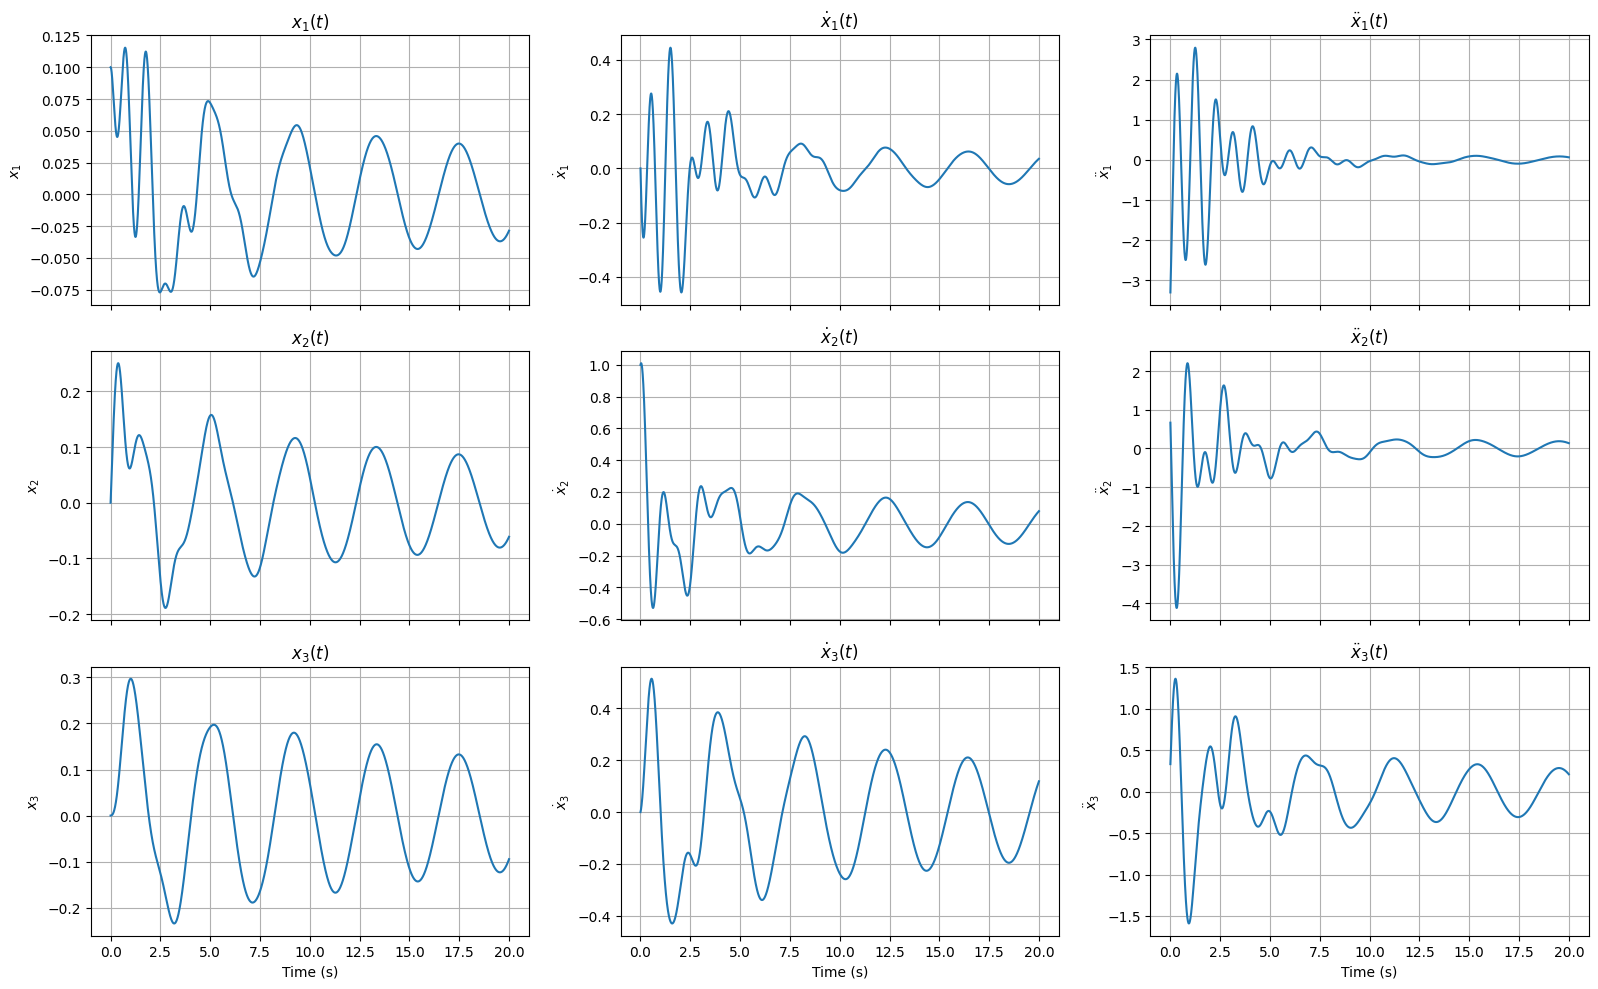

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Parameters: change these as you like
# --------------------------------------------------
m1, m2, m3 = 1.0, 1.2, 1.5
c1, c2, c3 = 0.8, 0.2, 0.5
k1, k2, k3 = 20.0, 15.0, 10.0

# Sinusoidal force parameters
F01, F02, F03 = 0.0, 0.0, 0.0      # amplitudes
w1, w2, w3 = 3.0, 3.0, 3.0         # forcing frequencies

# Time settings
dt = 0.001
t_end = 20.0
n = int(t_end / dt)

# Initial conditions
x0 = np.array([0.1, 0.0, 0.0])     # initial displacement
v0 = np.array([0.0, 1.0, 0.0])     # initial velocity

# --------------------------------------------------
# Matrices
# --------------------------------------------------
M = np.array([
    [m1, 0.0, 0.0],
    [0.0, m2, 0.0],
    [0.0, 0.0, m3]
])

C = np.array([
    [c1 + c2, -c2,      0.0],
    [-c2,      c2 + c3, -c3],
    [0.0,     -c3,      c3]
])

K = np.array([
    [k1 + k2, -k2,      0.0],
    [-k2,      k2 + k3, -k3],
    [0.0,     -k3,      k3]
])

M_inv = np.linalg.inv(M)

# --------------------------------------------------
# Arrays
# --------------------------------------------------
t = np.zeros(n + 1)
x = np.zeros((3, n + 1))
v = np.zeros((3, n + 1))
a = np.zeros((3, n + 1))
F = np.zeros((3, n + 1))

x[:, 0] = x0
v[:, 0] = v0

# --------------------------------------------------
# Force function
# --------------------------------------------------
def force_vector(time):
    return np.array([
        F01 * np.sin(w1 * time),
        F02 * np.sin(w2 * time),
        F03 * np.sin(w3 * time)
    ])

# Initial acceleration
F[:, 0] = force_vector(t[0])
a[:, 0] = M_inv @ (F[:, 0] - C @ v[:, 0] - K @ x[:, 0])

# --------------------------------------------------
# Euler method
# --------------------------------------------------
for i in range(n):
    t[i + 1] = t[i] + dt

    F[:, i] = force_vector(t[i])

    # Compute acceleration
    a[:, i] = M_inv @ (F[:, i] - C @ v[:, i] - K @ x[:, i])

    # Euler update
    x[:, i + 1] = x[:, i] + dt * v[:, i]
    v[:, i + 1] = v[:, i] + dt * a[:, i]

# Final force and acceleration
F[:, n] = force_vector(t[n])
a[:, n] = M_inv @ (F[:, n] - C @ v[:, n] - K @ x[:, n])

# --------------------------------------------------
# Plot: 3 rows x 3 columns
# --------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)

# Row 1: DOF 1
axes[0, 0].plot(t, x[0, :])
axes[0, 0].set_title(r'$x_1(t)$')
axes[0, 0].set_ylabel(r'$x_1$')
axes[0, 0].grid(True)

axes[0, 1].plot(t, v[0, :])
axes[0, 1].set_title(r'$\dot{x}_1(t)$')
axes[0, 1].set_ylabel(r'$\dot{x}_1$')
axes[0, 1].grid(True)

axes[0, 2].plot(t, a[0, :])
axes[0, 2].set_title(r'$\ddot{x}_1(t)$')
axes[0, 2].set_ylabel(r'$\ddot{x}_1$')
axes[0, 2].grid(True)

# Row 2: DOF 2
axes[1, 0].plot(t, x[1, :])
axes[1, 0].set_title(r'$x_2(t)$')
axes[1, 0].set_ylabel(r'$x_2$')
axes[1, 0].grid(True)

axes[1, 1].plot(t, v[1, :])
axes[1, 1].set_title(r'$\dot{x}_2(t)$')
axes[1, 1].set_ylabel(r'$\dot{x}_2$')
axes[1, 1].grid(True)

axes[1, 2].plot(t, a[1, :])
axes[1, 2].set_title(r'$\ddot{x}_2(t)$')
axes[1, 2].set_ylabel(r'$\ddot{x}_2$')
axes[1, 2].grid(True)

# Row 3: DOF 3
axes[2, 0].plot(t, x[2, :])
axes[2, 0].set_title(r'$x_3(t)$')
axes[2, 0].set_ylabel(r'$x_3$')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].grid(True)

axes[2, 1].plot(t, v[2, :])
axes[2, 1].set_title(r'$\dot{x}_3(t)$')
axes[2, 1].set_ylabel(r'$\dot{x}_3$')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].grid(True)

axes[2, 2].plot(t, a[2, :])
axes[2, 2].set_title(r'$\ddot{x}_3(t)$')
axes[2, 2].set_ylabel(r'$\ddot{x}_3$')
axes[2, 2].set_xlabel('Time (s)')
axes[2, 2].grid(True)

plt.tight_layout()
plt.show()

# Modal Parameters of a 3DoF System

## Undamped System Mathematical Model

Consider a multi-degree-of-freedom undamped system

$$
M\ddot{q} + Kq = 0
$$

where

- $M$ : mass matrix  
- $K$ : stiffness matrix  
- $q$ : displacement vector

---

## Exponential Solution Assumption

Assume the solution

$$
q(t) = u e^{st}
$$

where

- $u$ is the modal vector
- $s$ is a constant.

Substituting into the governing equation gives

$$
(K - \lambda M)u = 0
$$

where

$$
\lambda = -s^2
$$

For a nontrivial solution:

$$
\det(K - \lambda M) = 0
$$

This is the **generalized eigenvalue problem**.

---

## Mass Matrix Transformation

Because $M^{-1}K$ is generally **not symmetric**, we transform the system.

Let

$$
M = Q^T Q
$$

Define

$$
Qu = v
$$

Then

$$
(Q^T)^{-1}Ku = \lambda Qu
$$

which leads to

$$
(Q^T K Q^{-1})v = \lambda v
$$

Define

$$
A = (Q^T)KQ^{-1}
$$

Thus

$$
Av = \lambda v
$$

where $A$ is symmetric and has **real eigenvalues**.

---

# Example: 3DOF System

For a 3DOF undamped system

<p align="center">
<img src="three_dof_model.png" width="400">
</p>

Mass values

$$
m_1 = 2m, \quad m_2 = 3m, \quad m_3 = m
$$

Spring constants

$$
k_1 = 2k, \quad k_2 = 3k, \quad k_3 = 2k, \quad k_4 = k
$$

Damping constants

$$
c_1 = 0, \quad c_2 = 0, \quad c_3 = 0, \quad c_4 = 0
$$

---

## Stiffness Matrix

$$
K =
\begin{bmatrix}
k_1+k_2 & -k_2 & 0 \\
-k_2 & k_2+k_3 & -k_3 \\
0 & -k_3 & k_3+k_4
\end{bmatrix}
=
\begin{bmatrix}
5k & -3k & 0 \\
-3k & 5k & -2k \\
0 & -2k & 3k
\end{bmatrix}
$$

---

## Mass Matrix

$$
M =
\begin{bmatrix}
2m & 0 & 0 \\
0 & 3m & 0 \\
0 & 0 & m
\end{bmatrix}
$$

---

## Eigenvalue Problem

We solve

$$
Av = \lambda v
$$

which gives

$$
\lambda_1 = 0.4256 \frac{k}{m}
$$

$$
\lambda_2 = 2.741 \frac{k}{m}
$$

$$
\lambda_3 = 4 \frac{k}{m}
$$

---

## Mode Shapes (Eigenvectors)

$$
v_1 =
\begin{bmatrix}
0.4743 \\
0.8033 \\
0.3603
\end{bmatrix}
$$

$$
v_2 =
\begin{bmatrix}
-0.7435 \\
0.1463 \\
0.6525
\end{bmatrix}
$$

$$
v_3 =
\begin{bmatrix}
0.4714 \\
-0.5774 \\
0.6667
\end{bmatrix}
$$

---

## Physical Mode Shapes

The physical mode shapes are

$$
u = Q^{-1}v
$$

giving

$$
u_1 =
\frac{1}{\sqrt{m}}
\begin{bmatrix}
0.3354 \\
0.4638 \\
0.3604
\end{bmatrix}
$$

$$
u_2 =
\frac{1}{\sqrt{m}}
\begin{bmatrix}
-0.5257 \\
0.0845 \\
0.6525
\end{bmatrix}
$$

$$
u_3 =
\frac{1}{\sqrt{m}}
\begin{bmatrix}
0.3333 \\
-0.3333 \\
0.6667
\end{bmatrix}
$$

---



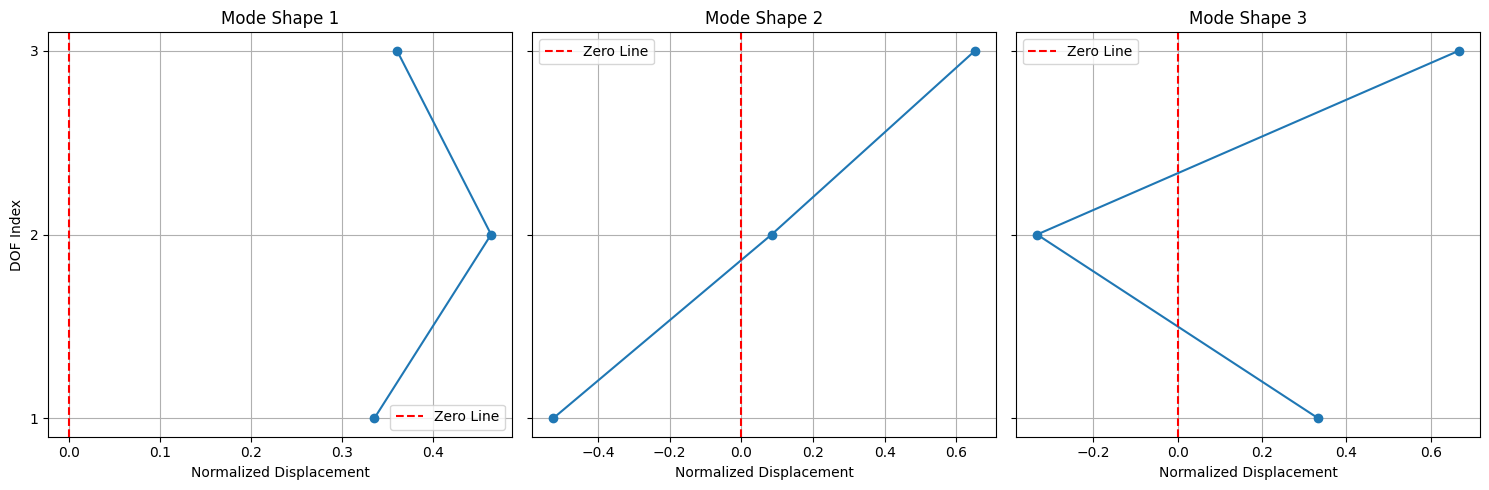

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Mode shapes
u1 = np.array([0.3354, 0.4638, 0.3604])
u2 = np.array([-0.5257, 0.0845, 0.6525])
u3 = np.array([0.3333, -0.3333, 0.6667])

modes = [u1, u2, u3]
titles = ["Mode Shape 1", "Mode Shape 2", "Mode Shape 3"]

dof = np.arange(1, 4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i in range(3):
    axes[i].plot(modes[i], dof, marker='o')
    axes[i].axvline(0, color='red', linestyle='--', label='Zero Line')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Normalized Displacement")
    axes[i].set_yticks(dof)
    axes[i].grid()
    axes[i].legend()

axes[0].set_ylabel("DOF Index")

plt.tight_layout()
plt.show()

# General Damped System

The general damped system is

$$
M\ddot{q} + C\dot{q} + Kq = 0
$$

Define the state variables

$$
z_1 = \dot{q}, \quad z_2 = q
$$

Thus

$$
z =
\begin{Bmatrix}
\dot{q} \\
q
\end{Bmatrix}
$$

The system becomes

$$
\dot{z}_2 - z_1 = 0
$$

$$
M\dot{z}_1 + Cz_2 + Kz_1 = 0
$$

or in matrix form

$$
M^*\dot{z} + K^* z = 0
$$

Assume

$$
z = u e^{\alpha t}
$$

then

$$
(K^* - \lambda M^*)u = 0
$$

where

$$
\lambda = -\alpha
$$

Because the modified mass matrix is not positive definite, the eigenvalues and eigenvectors may have **real and imaginary parts**.